# Checking results in summary.json files generated by nnUNet

In [1]:
# imports
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import colormaps
import seaborn as sns
from scipy.stats import ttest_rel
from scipy.stats import wilcoxon
import SimpleITK as sitk

In [2]:
# path to predicted data
data_path = '../nnUNet_data/nnUNet_raw/Dataset361_Menisci/iwoai_internal_results/'

# list subfolders at this path
subfolders = [f.name for f in os.scandir(data_path) if f.is_dir()]
print(subfolders)

['nyul_fold_predsTs', 'clip_and_rescale_fold_predsTs', 'rescale_predsTs', 'clahe_predsTs', 'hist_eq_fold_predsTs', 'gmm_predsTs', 'clahe_fold_predsTs', 'nyul_predsTs', 'zscore_hist_match_predsTs', 'gmm_fold_predsTs', 'ResEnc_3d_bs4_predsTs', 'hist_eq_predsTs', 'rescale_fold_predsTs', 'zscore_fold_predsTs', 'ResEnc_32G_3d_predsTs', 'zscore_predsTs', 'clip_rescale_predsTs']


In [3]:
# what metrics are there?
json_path = os.path.join(data_path, 'clahe_predsTs', 'summary.json')

with open(json_path) as f:
    data = json.load(f)

# extract all metrics
data["metric_per_case"][1]

{'metrics': {'1': {'Dice': 0.9256669400692311,
   'FN': 4770,
   'FP': 5924,
   'Hausdorff': 3.3621199131011963,
   'Hausdorff_95': 0.8161648511886597,
   'IoU': 0.861620082815735,
   'TN': 8114720,
   'TP': 66586,
   'n_pred': 72510,
   'n_ref': 71356}},
 'prediction_file': 'clahe_predsTs/IWOAI_002.nii.gz',
 'reference_file': 'labelsTs/IWOAI_002.nii.gz'}

In [4]:
# functions to take json file and return array of dice scores, or return hausdorff distance
def get_dice_scores(json_file):
    with open(json_file) as f:
        data = json.load(f)

    # Extract Dice scores from "metric_per_case"
    dice_scores = [
        case["metrics"]["1"]["Dice"] for case in data["metric_per_case"]
    ]

    return dice_scores


def get_hausdorff_distances(json_file):
    with open(json_file) as f:
        data = json.load(f)

    # Extract Hausdorff distances from "metric_per_case"
    hausdorff_distances = [
        case["metrics"]["1"]["Hausdorff_95"] for case in data["metric_per_case"]
    ]

    return hausdorff_distances

In [5]:
# get only the subfolders that don't contain skmtea
subfolders = [f.name for f in os.scandir(data_path) if f.is_dir() and not f.name.endswith("skmtea")]

# discount images and labels folders (starts with)
subfolders = [f for f in subfolders if not f.startswith("images") and not f.startswith("labels")]

# discount folders that start with ResEnc
subfolders = [f for f in subfolders if not f.startswith("ResEnc")]

# discount hist match
subfolders = [f for f in subfolders if "hist_match" not in f]

# discount fold folders
subfolders = [f for f in subfolders if "fold" not in f]

subfolders

['rescale_predsTs',
 'clahe_predsTs',
 'gmm_predsTs',
 'nyul_predsTs',
 'hist_eq_predsTs',
 'zscore_predsTs',
 'clip_rescale_predsTs']

In [6]:
# reorder the subfolders using the order of the methods (starts with)
method_order = ["zscore_preds", "rescale", "clip_rescale", "hist_eq", "clahe_preds", "nyul", "gmm"]

# Sort by checking which method each subfolder starts with
subfolders = sorted(
    subfolders,
    key=lambda x: next((method_order.index(m) for m in method_order if x.lower().startswith(m.lower())), float('inf'))
)
subfolders

['zscore_predsTs',
 'rescale_predsTs',
 'clip_rescale_predsTs',
 'hist_eq_predsTs',
 'clahe_predsTs',
 'nyul_predsTs',
 'gmm_predsTs']

In [7]:
# for each folder, get dice scores and add to pandas dataframe

# create empty dataframe
internal_df = pd.DataFrame()

for folder in subfolders:
    json_path = os.path.join(data_path, folder, 'summary.json')
    dice_scores = get_dice_scores(json_path)
    internal_df[folder] = dice_scores

column_names = [
    "Z-score",
    "Min-max",
    "R. Min-max",
    "HE",
    "CLAHE",
    "Nyúl",
    "GMM"
]

internal_df.columns = column_names

# turn dice to percentage
internal_df = internal_df * 100
internal_df.describe()

,Z-score,Min-max,R. Min-max,HE,CLAHE,Nyúl,GMM
count,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000
mean,89.231868,89.273201,89.089326,88.875942,89.056252,89.146737,89.254174
std,2.760574,2.772855,2.775203,2.910537,3.026974,2.697457,2.769961
min,82.105245,82.268511,81.777778,81.996804,81.669719,82.126683,82.093138
25%,88.138653,87.932464,87.674429,87.257726,87.268012,87.965681,87.871070
50%,89.885006,89.844768,89.532192,89.412692,89.643142,89.718416,89.854431
75%,90.822710,91.001905,90.841774,91.181378,90.756799,90.617817,90.827014
max,92.796221,93.033005,92.693310,92.846574,93.086310,93.073363,92.998669


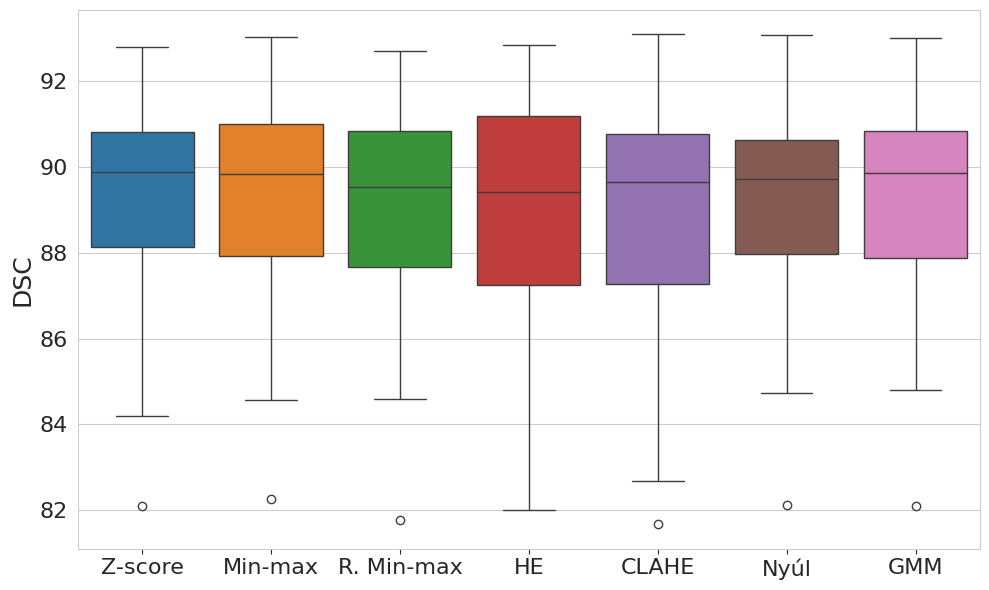

In [8]:
sns.set_style("whitegrid", {'xtick.bottom': True})

# plot box plot of dice scores
plt.figure(figsize=(10, 6))
sns.boxplot(data=internal_df)
plt.ylabel("DSC", fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.savefig('boxplot_internal_dice_scores.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# get array of average internal dice scores
internal_dice_means = internal_df.mean()

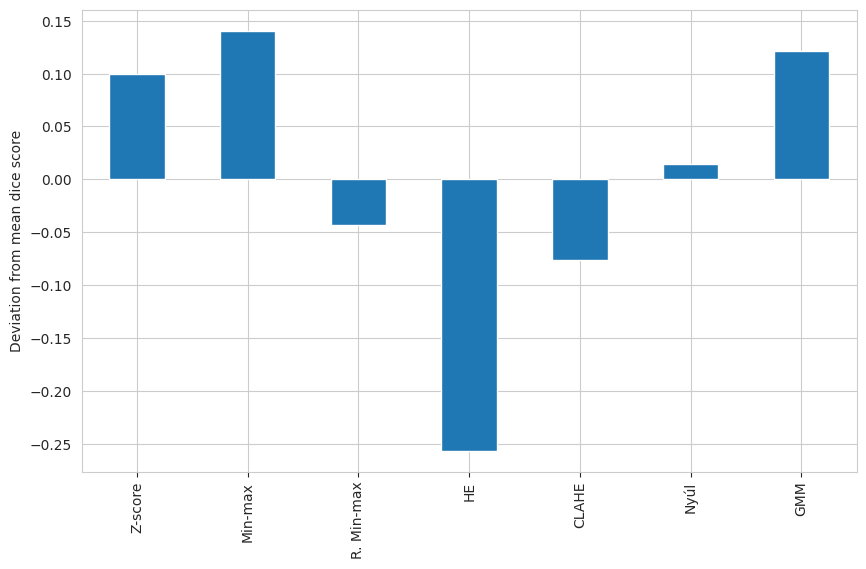

In [10]:
# now get amount each method deviates from the mean of methods
mean_of_method_means = internal_dice_means.mean()
internal_dice_deviations = internal_dice_means - mean_of_method_means

# plot bar chart of deviations
plt.figure(figsize=(10, 6))
internal_dice_deviations.plot(kind='bar')
plt.ylabel("Deviation from mean dice score")
plt.show()

In [11]:
internal_df.corr('pearson')

,Z-score,Min-max,R. Min-max,HE,CLAHE,Nyúl,GMM
Z-score,1.000000,0.996629,0.992293,0.972603,0.984850,0.993555,0.996807
Min-max,0.996629,1.000000,0.996064,0.980222,0.978346,0.991621,0.997343
R. Min-max,0.992293,0.996064,1.000000,0.984184,0.972255,0.989541,0.994929
HE,0.972603,0.980222,0.984184,1.000000,0.954537,0.972940,0.978881
CLAHE,0.984850,0.978346,0.972255,0.954537,1.000000,0.974481,0.975380
Nyúl,0.993555,0.991621,0.989541,0.972940,0.974481,1.000000,0.994217
GMM,0.996807,0.997343,0.994929,0.978881,0.975380,0.994217,1.000000


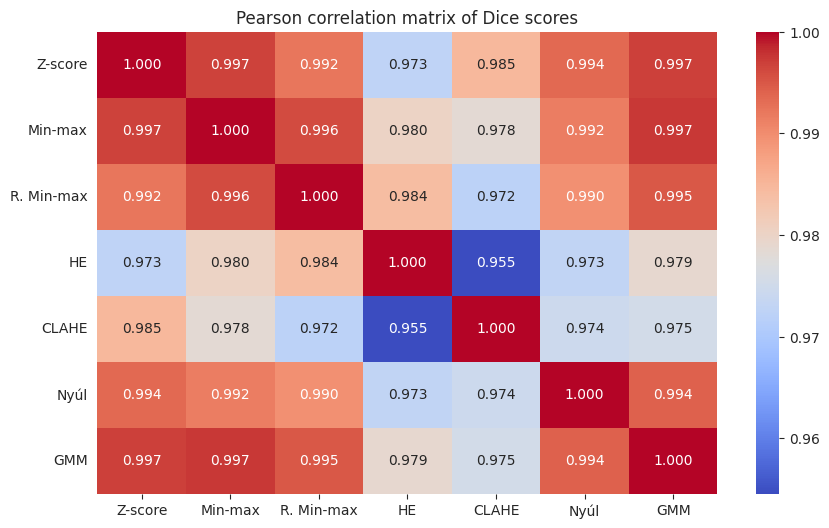

In [12]:
# plot pairwise correlation matrix of dice scores, to 3 decimal places
plt.figure(figsize=(10, 6))
sns.heatmap(internal_df.corr('pearson'), annot=True, cmap='coolwarm', fmt=".3f")
plt.title("Pearson correlation matrix of Dice scores")
plt.show()

In [13]:
# get medians
internal_dice_medians = internal_df.median()

# order columns by decreasing median
internal_dice_medians = internal_dice_medians.sort_values(ascending=False)

In [14]:
# Perform non-parametric repeated measures ANOVA between all methods 
# using Friedman test
from scipy.stats import friedmanchisquare

# reorder data into correct format
data = internal_df.T.values

# perform friedman test
stat, p = friedmanchisquare(*data)
print(f"Friedman test statistic: {stat}, p-value: {p}")
# if p < 0.05, perform post-hoc tests
if p < 0.05:
    print("Friedman test is significant, can post-hoc tests")

Friedman test statistic: 26.12755102040819, p-value: 0.00021078438937070077
Friedman test is significant, can post-hoc tests


In [15]:
print("Medians:\n",internal_dice_medians)

Medians:
 Z-score       89.885006
GMM           89.854431
Min-max       89.844768
Nyúl          89.718416
CLAHE         89.643142
R. Min-max    89.532192
HE            89.412692
dtype: float64


In [16]:
internal_dice_means = internal_dice_means.sort_values(ascending=False)
print("Means:\n",internal_dice_means)

Means:
 Min-max       89.273201
GMM           89.254174
Z-score       89.231868
Nyúl          89.146737
R. Min-max    89.089326
CLAHE         89.056252
HE            88.875942
dtype: float64


In [17]:
# Use Bonferroni correction for multiple comparisons
methods = internal_dice_means.index.tolist()

# number of comparisons
n_comparisons = len(methods) * (len(methods) - 1) / 2
alpha = 0.05 / n_comparisons
print(f"Bonferroni corrected alpha: {alpha}")

# for each pair of methods, perform wilcoxon test
p_values = np.zeros((len(methods), len(methods)))

for i, method1 in enumerate(methods):
    for j, method2 in enumerate(methods):
        if i < j:
            t_stat, p_val = wilcoxon(internal_df[method1], internal_df[method2])
            significant = "(SIG)" if p_val < alpha else ""
            if p_val < alpha:
                print(f"{method1} vs {method2}: p-value = {p_val:.7f} {significant}")

            # save p-values to triangular matrix
            p_values[i, j] = p_val

print(p_values)

Bonferroni corrected alpha: 0.002380952380952381
Min-max vs R. Min-max: p-value = 0.0005834 (SIG)
Min-max vs HE: p-value = 0.0001937 (SIG)
GMM vs HE: p-value = 0.0007162 (SIG)
[[0.00000000e+00 8.66507784e-01 3.50162961e-01 1.37518100e-01
  5.83387911e-04 2.26976871e-01 1.93685293e-04]
 [0.00000000e+00 0.00000000e+00 7.28165634e-01 9.92795080e-02
  3.73861939e-03 4.93233666e-01 7.16209412e-04]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 1.85784921e-01
  2.98331901e-02 2.94598028e-01 2.90198624e-03]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  3.98947045e-01 1.00000000e+00 1.36236995e-02]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 4.65176210e-01 1.78869143e-02]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 1.19971372e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00]]


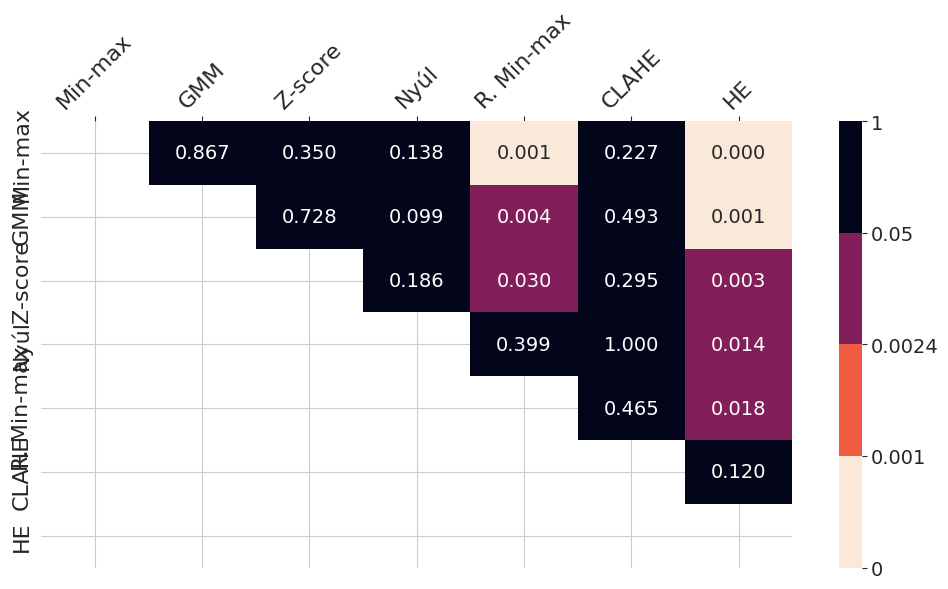

In [18]:
df_p_values = pd.DataFrame(p_values, index=methods, columns=methods)
# convert p-values using bonferroni correction
df_p_values_bonf = df_p_values.map(lambda x: min(x * n_comparisons, 1))

# make heatmap of p-values
cmap = colormaps["rocket"]

bad = cmap(0)
low_sig = cmap(0.33)
high_sig= cmap(0.66)
max_sig = cmap(0.99)

# Define custom color mapping
colours = [max_sig, high_sig, low_sig, bad]
# normal significance levels
sig_levels = [0, 0.001, 0.0024, 0.05]
bounds = np.append(np.array(sig_levels), [1]) # Boundaries: 0 → 0.001 → 0.0024 → 0.05 → 1
ticks = sig_levels + [1]

# Create a colormap
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colours, N=256)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(10, 6))
ax = sns.heatmap(df_p_values, annot=True, cmap=cmap, norm=norm, fmt=".3f", mask=df_p_values==0, vmin=0, vmax=1, annot_kws={"size": 14})

# Set custom colorbar ticks and labels
cbar = ax.collections[0].colorbar
cbar.set_ticks(bounds)  # Explicitly include 0.0024
# add '/alpha' to sig_levels
tick_labels = [f"{t}" if t != int(t) else f"{t}" for t in ticks]
cbar.set_ticklabels(tick_labels)  # Force 0.0024 as a label
cbar.ax.tick_params(labelsize=14)

# move x ticks to top
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

# Adjust tick labels
plt.xticks(fontsize=16, rotation=45)
plt.yticks(fontsize=16)

plt.tight_layout()
plt.savefig('p_values_internal_dice_scores.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
np.array(sig_levels)/n_comparisons

array([0.00000000e+00, 4.76190476e-05, 1.14285714e-04, 2.38095238e-03])

In [20]:
# Repeat pairwise wilcoxon but with different correction
# use benjamini-hochberg correction for multiple comparisons
from statsmodels.stats.multitest import multipletests

methods = internal_dice_medians.index.tolist()

# get all p-values
p_values = []
comparisons = []
for i, method1 in enumerate(methods):
    for j, method2 in enumerate(methods):
        if i < j:
            t_stat, p_val = wilcoxon(internal_df[method1], internal_df[method2])
            p_values.append(p_val)
            comparisons.append((method1, method2))
# apply benjamini-hochberg correction
corrected_pvals = multipletests(p_values, method='fdr_bh')[1]
# print significant results
for i, (method1, method2) in enumerate(comparisons):
    if corrected_pvals[i] < 0.05:
        print(f"{method1} vs {method2}: p-value = {corrected_pvals[i]:.7f} (BH corrected)")


Z-score vs HE: p-value = 0.0152354 (BH corrected)
GMM vs R. Min-max: p-value = 0.0157022 (BH corrected)
GMM vs HE: p-value = 0.0050135 (BH corrected)
Min-max vs R. Min-max: p-value = 0.0050135 (BH corrected)
Min-max vs HE: p-value = 0.0040674 (BH corrected)
Nyúl vs HE: p-value = 0.0476829 (BH corrected)


In [21]:
!pip install statsmodels

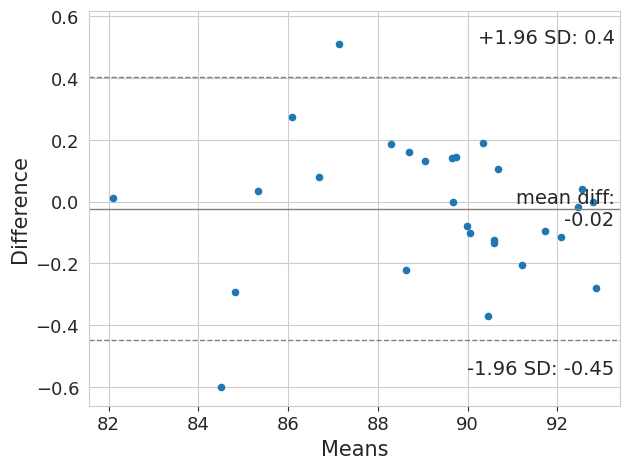

In [21]:
# plot bland-altman for zscore vs rescale (means and differences)
import statsmodels.api as sm
sm.graphics.mean_diff_plot(internal_df["Z-score"], internal_df["GMM"])
#plt.savefig('bland_altman_zscore_rescale.eps', format='eps', bbox_inches='tight')
plt.show()

In [22]:
# now get hausdorff distances for each method
internal_hd_df = pd.DataFrame()

for folder in subfolders:
    json_path = os.path.join(data_path, folder, 'summary.json')
    hausdorff_distances = get_hausdorff_distances(json_path)
    internal_hd_df[folder] = hausdorff_distances

internal_hd_df.columns = column_names

internal_hd_df.describe()

,Z-score,Min-max,R. Min-max,HE,CLAHE,Nyúl,GMM
count,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000
mean,1.484182,1.467825,1.486729,1.504250,1.498788,1.474521,1.456220
std,0.674026,0.651158,0.619257,0.657657,0.671274,0.650246,0.609876
min,0.730000,0.730000,0.730000,0.730000,0.730000,0.730000,0.730000
25%,0.962580,0.962580,0.991717,1.011385,1.011385,1.011385,0.962580
50%,1.400000,1.400000,1.400000,1.400000,1.400000,1.400000,1.400000
75%,2.042078,2.087700,1.901549,1.810305,1.954642,1.789273,2.057081
max,3.500000,3.421041,3.500000,3.500000,3.500000,3.500000,3.157784


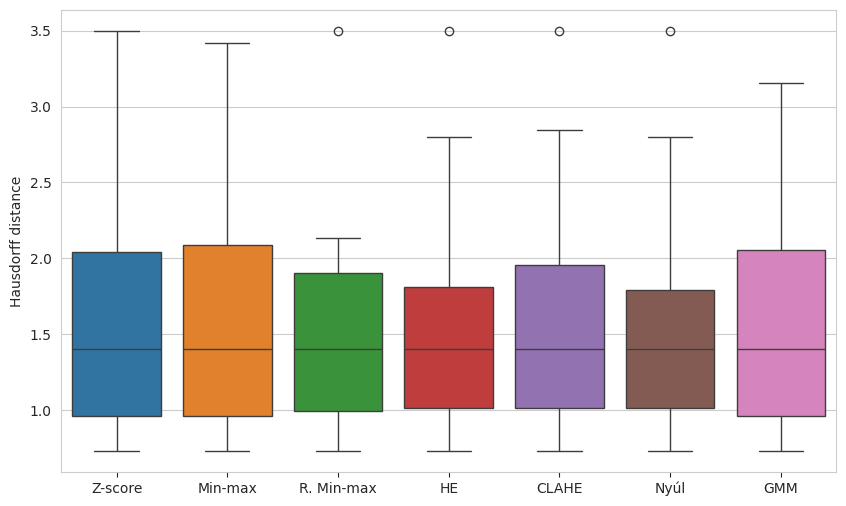

In [23]:
# plot box plot of hausdorff distances
plt.figure(figsize=(10, 6))
sns.boxplot(data=internal_hd_df)
plt.ylabel("Hausdorff distance")
plt.savefig('boxplot_internal_hausdorff_distances.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [24]:
# check if there is a significant difference between the methods
# Friedman test

# reorder data into correct format
data = internal_hd_df.T.values
# perform friedman test
stat, p = friedmanchisquare(*data)
print(f"Friedman test statistic: {stat}, p-value: {p}")
# if p < 0.05, perform post-hoc tests
if p < 0.05:
    print("Friedman test is significant, can post-hoc tests")

Friedman test statistic: 13.980861244019051, p-value: 0.029850686580758526
Friedman test is significant, can post-hoc tests


In [25]:
# check if there is a significant difference between the methods
# perform wilcoxon test between all pairs of methods
# Use Bonferroni correction for multiple comparisons
methods = internal_hd_df.columns.tolist()
# number of comparisons
n_comparisons = len(methods) * (len(methods) - 1) / 2
alpha = 0.05 / n_comparisons

print(f"Bonferroni corrected alpha: {alpha}")
# for each pair of methods, perform wilcoxon test
for i, method1 in enumerate(methods):
    for j, method2 in enumerate(methods):
        if i < j:
            t_stat, p_val = wilcoxon(internal_hd_df[method1], internal_hd_df[method2])
            significant = "(SIG)" if p_val < alpha else ""
            if p_val < 0.1:
                print(f"{method1} vs {method2}: p-value = {p_val:.7f} {significant}")

Bonferroni corrected alpha: 0.002380952380952381
R. Min-max vs GMM: p-value = 0.0935645 
CLAHE vs GMM: p-value = 0.0853519 


## External Validation Results

In [26]:
data_path = '../nnUNet_data/nnUNet_raw/Dataset361_Menisci/skmtea_test_fold_results/'

# get only the subfolders that don't contain skmtea
subfolders = [f.name for f in os.scandir(data_path) if f.is_dir() and f.name.endswith("Ts_skmtea")]

# discount images and labels folders (starts with)
subfolders = [f for f in subfolders if not f.startswith("images") and not f.startswith("labels")]

# discount folders that start with ResEnc
subfolders = [f for f in subfolders if not f.startswith("ResEnc")]

# discount hist match
subfolders = [f for f in subfolders if "hist_match" not in f]

subfolders

['clip_rescale_predsTs_skmtea',
 'rescale_predsTs_skmtea',
 'zscore_predsTs_skmtea',
 'clahe_predsTs_skmtea',
 'hist_eq_predsTs_skmtea']

In [27]:
# sort folders
subfolders = sorted(
    subfolders,
    key=lambda x: next((method_order.index(m) for m in method_order if x.lower().startswith(m.lower())), float('inf'))
)

subfolders

['zscore_predsTs_skmtea',
 'rescale_predsTs_skmtea',
 'clip_rescale_predsTs_skmtea',
 'hist_eq_predsTs_skmtea',
 'clahe_predsTs_skmtea']

In [28]:
# create empty dataframe
external_df = pd.DataFrame()

for folder in subfolders:
    json_path = os.path.join(data_path, folder, 'summary.json')
    dice_scores = get_dice_scores(json_path)
    external_df[folder] = dice_scores

external_df.columns = column_names

external_df.describe()

ValueError: Length mismatch: Expected axis has 5 elements, new values have 7 elements

In [ ]:
# plot box plot of dice scores
plt.figure(figsize=(10, 6))
sns.boxplot(data=external_df)
plt.ylabel("Dice score")
plt.savefig('boxplot_external_dice_scores.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# remove outlier

In [ ]:
# plot box plot of dice scores
plt.figure(figsize=(10, 6))
sns.boxplot(data=external_df[external_df["Zscore"] > 0.7])
plt.ylabel("Dice score")
plt.savefig('boxplot_external_dice_scores_no_outliers.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Are any of the differences statistically significant?
from scipy.stats import ttest_rel

# perform t-test between all pairs of methods
methods = external_df.columns
for method1 in methods:
    for method2 in methods:
        if method2 == method1:
            continue
        
        t_stat, p_val = ttest_rel(external_df[method1], external_df[method2], alternative="greater")
        significant = "(SIG)" if p_val < 0.05 else ""
        if p_val < 0.05:
            print(f"{method1} vs {method2}: p-value = {p_val:.4f} {significant}")

In [ ]:
from scipy.stats import wilcoxon

# perform wilcoxon signed-rank test between all pairs of methods
methods = external_df.columns
for method1 in methods:
    for method2 in methods:
        if method2 == method1:
            continue
        
        t_stat, p_val = wilcoxon(external_df[method1], external_df[method2], alternative="greater")
        significant = "(SIG)" if p_val < 0.05 else ""
        if p_val < 0.05:
            print(f"{method1} vs {method2}: p-value = {p_val:.4f} {significant}")

In [ ]:
# get hausdorff distances for each method
external_hd_df = pd.DataFrame()

for folder in subfolders:
    json_path = os.path.join(data_path, folder, 'summary.json')
    hausdorff_distances = get_hausdorff_distances(json_path)
    external_hd_df[folder] = hausdorff_distances

external_hd_df.columns = column_names

external_hd_df.describe()

In [ ]:
# plot box plot of hausdorff distances
plt.figure(figsize=(10, 6))
sns.boxplot(data=external_hd_df)
plt.ylabel("Hausdorff distance")
plt.savefig('boxplot_external_hausdorff_distances.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

## Check outlier cases

In [ ]:
external_df.head()

In [ ]:
# external image 3 has a very low dice score for all methods
# let's look at this image
# skmtea paths
im_num = 2 # indexing starts at 0
skmtea_im_path = os.path.join(data_path, 'imagesTs_skmtea')
image_paths = [f.path for f in os.scandir(skmtea_im_path) if f.is_file()]
image_paths.sort()
bad_image_path = image_paths[im_num]

# load image (.nii.gz)
image = sitk.ReadImage(bad_image_path)
image_array = sitk.GetArrayFromImage(image)
print(image_array.shape)

# plot image
plt.figure(figsize=(10, 6))
plt.imshow(image_array[100,...], cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
# load mask
skmtea_mask_path = os.path.join(data_path, 'labelsTs_skmtea')
mask_paths = [f.path for f in os.scandir(skmtea_mask_path) if f.is_file()]
mask_paths.sort()
mask_path = mask_paths[im_num]
mask = sitk.ReadImage(mask_path)
mask_array = sitk.GetArrayFromImage(mask)
print(mask_array.shape)

In [ ]:
# load prediction
zscore_preds_path = os.path.join(data_path, 'zscore_predsTs_skmtea')
pred_paths = [f.path for f in os.scandir(zscore_preds_path) if f.is_file()]
pred_paths.sort()
pred_path = pred_paths[im_num]
pred = sitk.ReadImage(pred_path)
pred_array = sitk.GetArrayFromImage(pred)
print(pred_array.shape)

In [ ]:
# plot both mask and prediction, summing through axis 1
plt.figure(figsize=(18, 10))
plt.subplot(1, 2, 1)
plt.imshow(np.sum(mask_array, axis=1), cmap="gray")
plt.title("Mask")
plt.subplot(1, 2, 2)
plt.imshow(np.sum(pred_array, axis=1), cmap="gray")
plt.title("Prediction")
plt.show()

In [ ]:
# look at slice 115-125, slice by slice (image on left and mask on right)
for i in range(115, 125):
    plt.figure(figsize=(18, 10))
    plt.subplot(1, 3, 1)
    plt.imshow(image_array[i,...], cmap="gray")
    plt.title("Image")
    plt.axis("off")
    plt.subplot(1, 3, 2)
    plt.imshow(mask_array[i,...], cmap="gray")
    plt.title("Mask")
    plt.axis("off")
    plt.subplot(1, 3, 3)
    plt.imshow(pred_array[i,...], cmap="gray")
    plt.title("Prediction")
    plt.axis("off")
    plt.show()

In [ ]:
# look at slice 170 in the z direction on image mask and prediction, rotated 90 degrees
plt.figure(figsize=(18, 10))
plt.subplot(1, 3, 1)
plt.imshow(np.rot90(image_array[...,170]), cmap="gray", aspect = (0.31/0.8))
plt.title("Image")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(np.rot90(mask_array[...,170]), cmap="gray", aspect = (0.31/0.8))
plt.title("Mask")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(np.rot90(pred_array[...,170]), cmap="gray", aspect = (0.31/0.8))
plt.title("Prediction")
plt.axis("off")
plt.show()

## Do External Validation on whole of SKMTEA

In [29]:
data_path = '../nnUNet_data/nnUNet_raw/Dataset361_Menisci/skmtea_external_results/'

# get only the subfolders that end in _all_skmtea
subfolders = [f.name for f in os.scandir(data_path) if f.is_dir() and f.name.endswith("_all_skmtea")]

# discount images and labels folders (starts with)
subfolders = [f for f in subfolders if not f.startswith("images") and not f.startswith("labels") 
              and not f.startswith("ResEnc") and not f.startswith("clahe_hist_match")
              and not f.startswith("zscore_postproc") and "hist_match" not in f and "fold" not in f]
subfolders

['clip_rescale_preds_all_skmtea',
 'nyul_preds_all_skmtea',
 'gmm_preds_all_skmtea',
 'zscore_preds_all_skmtea',
 'clahe_preds_all_skmtea',
 'rescale_preds_all_skmtea',
 'hist_eq_preds_all_skmtea']

In [30]:
# reorder the subfolders using the order of the methods (starts with)
method_order = ["zscore_preds", "rescale", "clip_rescale", "hist_eq", "clahe_preds", "resenc", "nyul", "gmm"]
# Sort by checking which method each subfolder starts with
subfolders = sorted(
    subfolders,
    key=lambda x: next((method_order.index(m) for m in method_order if x.lower().startswith(m.lower())), float('inf'))
)
subfolders

['zscore_preds_all_skmtea',
 'rescale_preds_all_skmtea',
 'clip_rescale_preds_all_skmtea',
 'hist_eq_preds_all_skmtea',
 'clahe_preds_all_skmtea',
 'nyul_preds_all_skmtea',
 'gmm_preds_all_skmtea']

In [31]:
# for each folder, get dice scores and add to pandas dataframe

# create empty dataframe
external_all_df = pd.DataFrame()

for folder in subfolders:
    json_path = os.path.join(data_path, folder, 'summary.json')
    dice_scores = get_dice_scores(json_path)
    external_all_df[folder] = dice_scores

# turn dice to percentage
external_all_df = external_all_df * 100
external_all_df.head()

,zscore_preds_all_skmtea,rescale_preds_all_skmtea,clip_rescale_preds_all_skmtea,hist_eq_preds_all_skmtea,clahe_preds_all_skmtea,nyul_preds_all_skmtea,gmm_preds_all_skmtea
0,80.279842,79.928753,80.192836,80.126713,80.330559,80.185203,79.931339
1,80.597486,80.664459,80.543079,79.832012,80.892747,80.880864,80.485006
2,82.420316,81.804615,82.013961,81.932241,81.715126,82.554881,81.935379
3,79.757396,79.706789,79.885147,79.510035,79.919987,79.360876,79.845018
4,82.373550,82.036228,82.280699,81.970770,82.547913,82.397004,81.892362


In [32]:
# rename columns
external_all_df.columns = [
    "Z-score",
    "Min-max",
    "R. Min-max",
    "HE",
    "CLAHE",
    "Nyúl",
    "GMM"
]

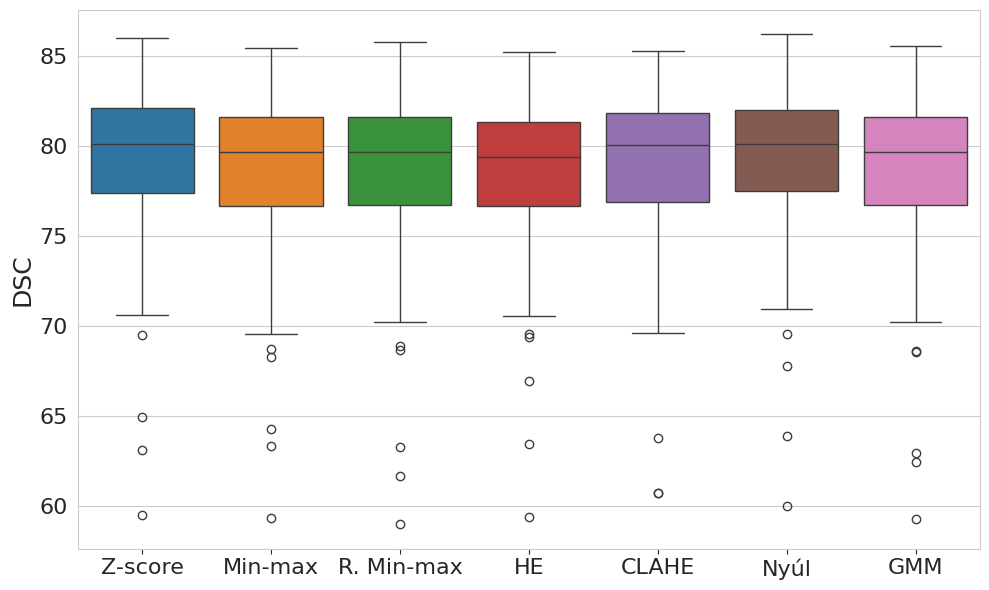

In [33]:
# plot box plot of dice scores
plt.figure(figsize=(10, 6))
sns.boxplot(data=external_all_df)
plt.ylabel("DSC", fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.savefig('boxplot_external_all_dice_scores.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

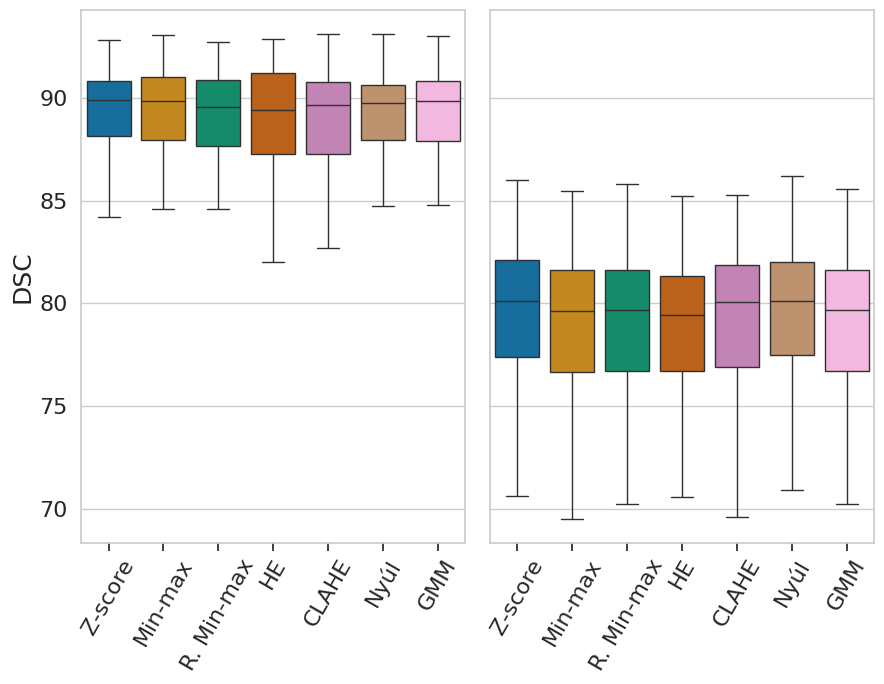

In [34]:
# now box plots of both internal and external
# as subplots with same y
sns.set_theme(palette="colorblind")
sns.set_style("whitegrid", {'xtick.bottom': True})
plt.subplots(1, 2, figsize=(9, 7), sharey=True)
plt.subplot(1, 2, 1)
sns.boxplot(data=internal_df, showfliers=False)
plt.ylabel("DSC", fontsize=18)
plt.xticks(fontsize=16, rotation=60)
plt.yticks(fontsize=16)
plt.subplot(1, 2, 2)
sns.boxplot(data=external_all_df, showfliers=False)
plt.ylabel("DSC", fontsize=18)
plt.xticks(fontsize=16, rotation=60)
plt.yticks(fontsize=16)

plt.tight_layout()
plt.savefig('boxplot_internal_external_dice_scores.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

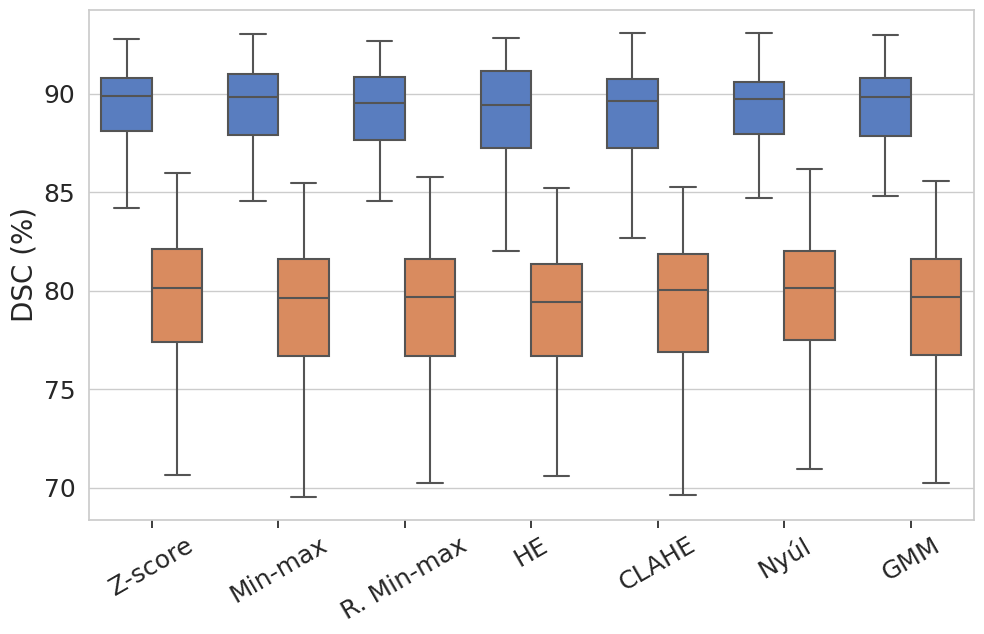

In [35]:
# now have both internal and external on same plot, grouped by method
# e.g. for zscore, internal and external are next to each other and a different color
# create new dataframe with internal and external data
internal_df["Type"] = "Internal"
external_all_df["Type"] = "External"
# combine dataframes
combined_df = pd.concat([internal_df, external_all_df], axis=0)
# melt dataframe to long format
combined_df = combined_df.melt(id_vars=["Type"], var_name="Method", value_name="DSC")

# Define different flier properties for each type
flierprops_internal = dict(marker='o', color='black', alpha=0.6, markersize=6)  # Circles for Internal
flierprops_external = dict(marker='x', color='red', alpha=0.8, markersize=6)  # X markers for External

# plot box plot of combined data
plt.figure(figsize=(10, 6.5))
sns.boxplot(data=combined_df, x="Method", y="DSC", hue="Type", showfliers=False, palette='muted', linewidth=1.5)

plt.ylabel("DSC (%)", fontsize=20)
# x label not needed
plt.xlabel("")
plt.xticks(fontsize=18, rotation=30)
plt.yticks(fontsize=18)
# no legend
plt.legend().set_visible(False)
plt.tight_layout()
plt.savefig('boxplot_internal_external_dice_scores_grouped.pdf', format='pdf', dpi=800, bbox_inches='tight')
plt.show()

In [36]:
# remove type column from external_all_df
external_all_df = external_all_df.drop(columns=["Type"])
external_all_df.mean()

Z-score       79.160507
Min-max       78.633094
R. Min-max    78.660079
HE            78.494181
CLAHE         79.040645
Nyúl          79.316759
GMM           78.625627
dtype: float64

Text(0, 0.5, 'Deviation from mean dice score')

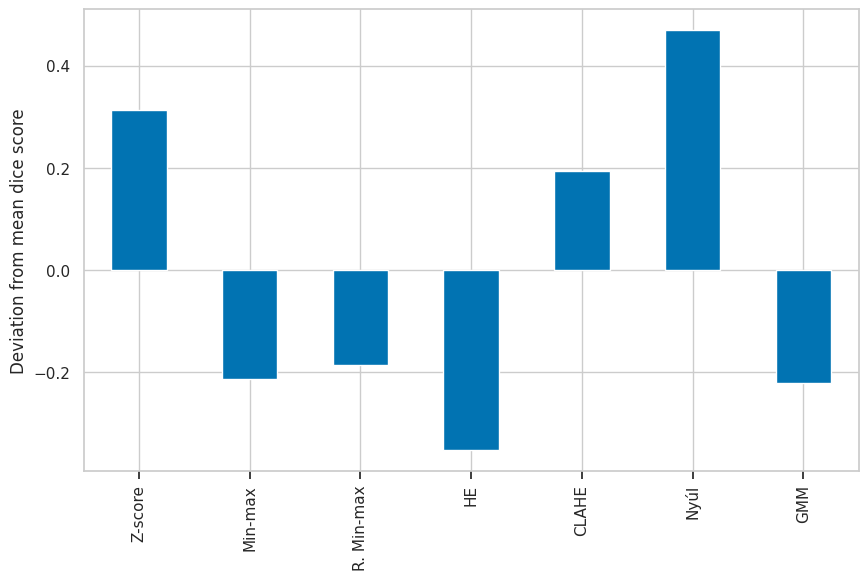

In [37]:
# mean of method dice scores
external_all_dice_means = external_all_df.mean()

# now get amount each method deviates from the mean of methods
mean_of_method_means = external_all_dice_means.mean()
external_all_dice_deviations = external_all_dice_means - mean_of_method_means

# plot bar chart of deviations
plt.figure(figsize=(10, 6))
external_all_dice_deviations.plot(kind='bar')
plt.ylabel("Deviation from mean dice score")

In [38]:
internal_dice_deviations

Z-score       0.099369
Min-max       0.140701
R. Min-max   -0.043174
HE           -0.256558
CLAHE        -0.076248
Nyúl          0.014237
GMM           0.121674
dtype: float64

Text(0, 0.5, 'Deviation difference from internal to external dice score')

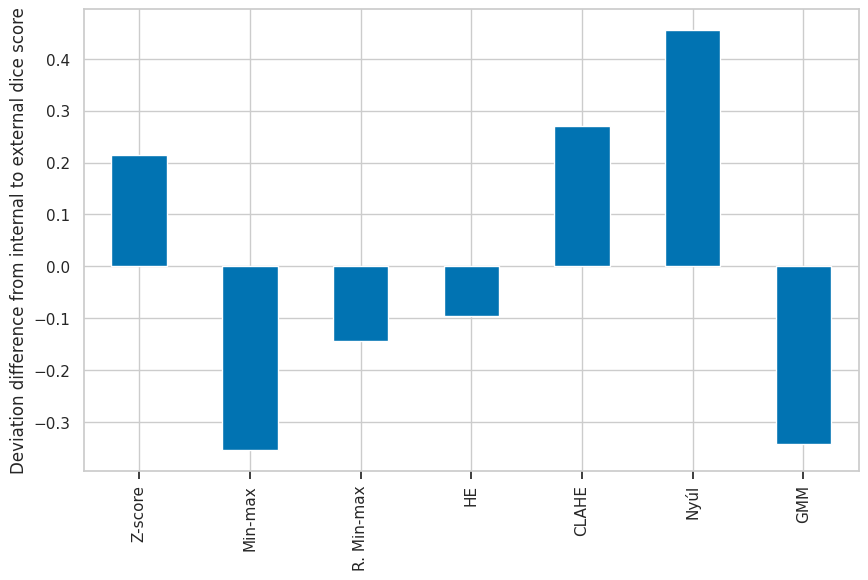

In [39]:
# plot the difference between internal and external mean deviation
deviation_difference = external_all_dice_deviations - internal_dice_deviations
plt.figure(figsize=(10, 6))
deviation_difference.plot(kind='bar')
plt.ylabel("Deviation difference from internal to external dice score")

(-0.12, -0.08)

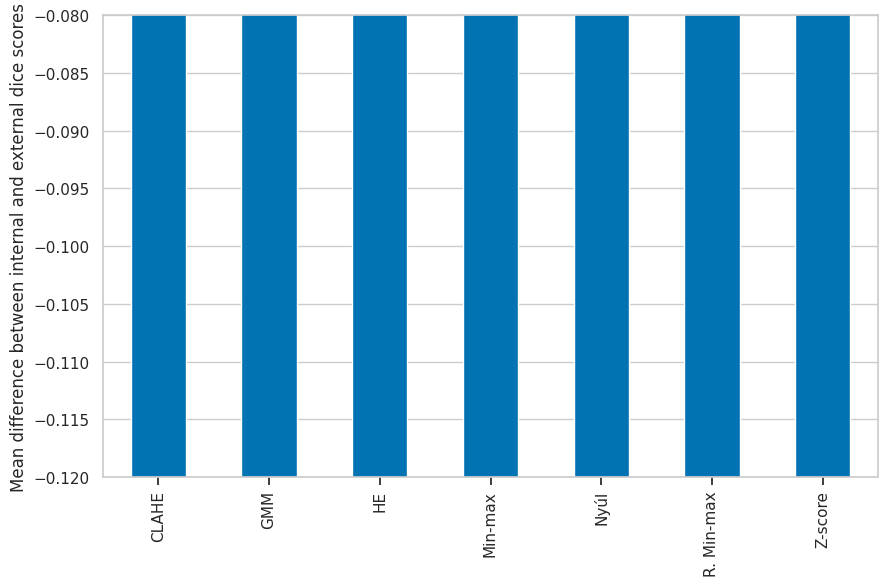

In [40]:
# now just plot the difference between internal and external dice score means
mean_difference = external_all_dice_means - internal_dice_means
plt.figure(figsize=(10, 6))
mean_difference.plot(kind='bar')
plt.ylabel("Mean difference between internal and external dice scores")

# axis range
plt.ylim(-0.12, -0.08)

In [41]:
mean_difference

CLAHE        -10.015606
GMM          -10.628547
HE           -10.381761
Min-max      -10.640106
Nyúl          -9.829977
R. Min-max   -10.429247
Z-score      -10.071361
dtype: float64

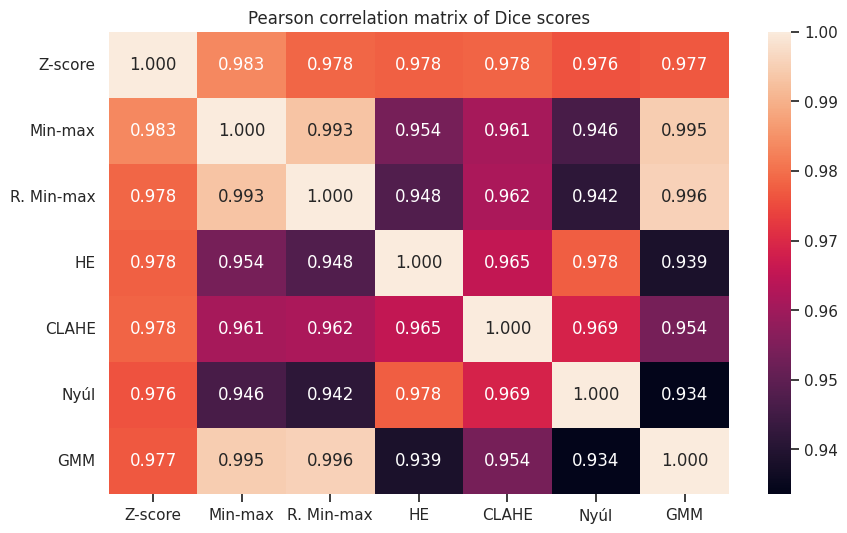

In [42]:
# plot pairwise correlation matrix of dice scores, to 3 decimal places
plt.figure(figsize=(10, 6))
sns.heatmap(external_all_df.corr('pearson'), annot=True, fmt=".3f")
plt.title("Pearson correlation matrix of Dice scores")
plt.show()

In [43]:
# get medians
external_all_dice_medians = external_all_df.median()
# order columns by decreasing median
external_all_dice_medians = external_all_dice_medians.sort_values(ascending=False)

In [44]:
external_all_dice_medians

Z-score       80.138983
Nyúl          80.133664
CLAHE         80.055370
R. Min-max    79.695130
GMM           79.670846
Min-max       79.649409
HE            79.419074
dtype: float64

In [45]:
external_all_dice_means = external_all_dice_means.sort_values(ascending=False)
external_all_dice_means

Nyúl          79.316759
Z-score       79.160507
CLAHE         79.040645
R. Min-max    78.660079
Min-max       78.633094
GMM           78.625627
HE            78.494181
dtype: float64

In [46]:
# Perform non-parametric repeated measures ANOVA between all methods
# using Friedman test
from scipy.stats import friedmanchisquare

# reorder data into correct format
data = external_all_df.T.values

# perform friedman test
stat, p = friedmanchisquare(*data)
print(f"Friedman test statistic: {stat}, p-value: {p}")
# if p < 0.05, perform post-hoc tests
if p < 0.05:
    print("Friedman test is significant, can post-hoc tests")

Friedman test statistic: 254.8479262672813, p-value: 3.773674358450171e-52
Friedman test is significant, can post-hoc tests


In [47]:
# print medians
print("Medians:\n",external_all_dice_medians)

Medians:
 Z-score       80.138983
Nyúl          80.133664
CLAHE         80.055370
R. Min-max    79.695130
GMM           79.670846
Min-max       79.649409
HE            79.419074
dtype: float64


In [48]:
# Use Bonferroni correction for multiple comparisons
methods = external_all_dice_means.index.tolist()
n_comparisons = len(methods) * (len(methods) - 1) / 2
alpha = 0.05 / n_comparisons

print(f"Bonferroni corrected alpha: {alpha}\n")

p_values_ext = np.zeros((len(methods), len(methods)))

# for each pair of methods, perform wilcoxon test
for i, method1 in enumerate(methods):
    for j, method2 in enumerate(methods):
        if i < j:
            t_stat, p_val = wilcoxon(external_all_df[method1], external_all_df[method2])
            significant = "(SIG)" if p_val < alpha else ""
            if p_val < alpha*100:
                print(f"{method1} vs {method2}: p-value = {p_val} {significant}")

            p_values_ext[i, j] = p_val

# turn to triangular matrix
p_val_ext_tri = np.triu(p_values_ext)
print(p_values_ext)
df_ext_p_values = pd.DataFrame(p_values_ext, index=methods, columns=methods)

Bonferroni corrected alpha: 0.002380952380952381

Nyúl vs Z-score: p-value = 0.18916268458225916 
Nyúl vs CLAHE: p-value = 0.0014913832420226259 (SIG)
Nyúl vs R. Min-max: p-value = 1.1893387939997891e-12 (SIG)
Nyúl vs Min-max: p-value = 4.1883216874356586e-14 (SIG)
Nyúl vs GMM: p-value = 1.2205082702682672e-12 (SIG)
Nyúl vs HE: p-value = 3.567746107152924e-20 (SIG)
Z-score vs CLAHE: p-value = 0.026017559704777923 
Z-score vs R. Min-max: p-value = 1.1462965430107789e-18 (SIG)
Z-score vs Min-max: p-value = 2.993315283055381e-21 (SIG)
Z-score vs GMM: p-value = 2.840017112270007e-23 (SIG)
Z-score vs HE: p-value = 2.0782151108438334e-17 (SIG)
CLAHE vs R. Min-max: p-value = 4.0688268179218525e-05 (SIG)
CLAHE vs Min-max: p-value = 7.011497998941913e-07 (SIG)
CLAHE vs GMM: p-value = 5.6991955823951424e-05 (SIG)
CLAHE vs HE: p-value = 6.45226051899409e-13 (SIG)
R. Min-max vs Min-max: p-value = 0.10477753857700725 
R. Min-max vs HE: p-value = 4.495516797401011e-08 (SIG)
Min-max vs GMM: p-value =

In [49]:
# convert p-values using bonferroni correction
df_ext_p_values_bonf = df_ext_p_values.applymap(lambda x: min(x * n_comparisons, 1))

/tmp/ipykernel_2353193/2385825345.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_ext_p_values_bonf = df_ext_p_values.applymap(lambda x: min(x * n_comparisons, 1))


In [50]:
def format_p_value(val):
    return "<0.001" if val < 0.001 else f"{val:.3f}"

(6, 6)
(6, 6)


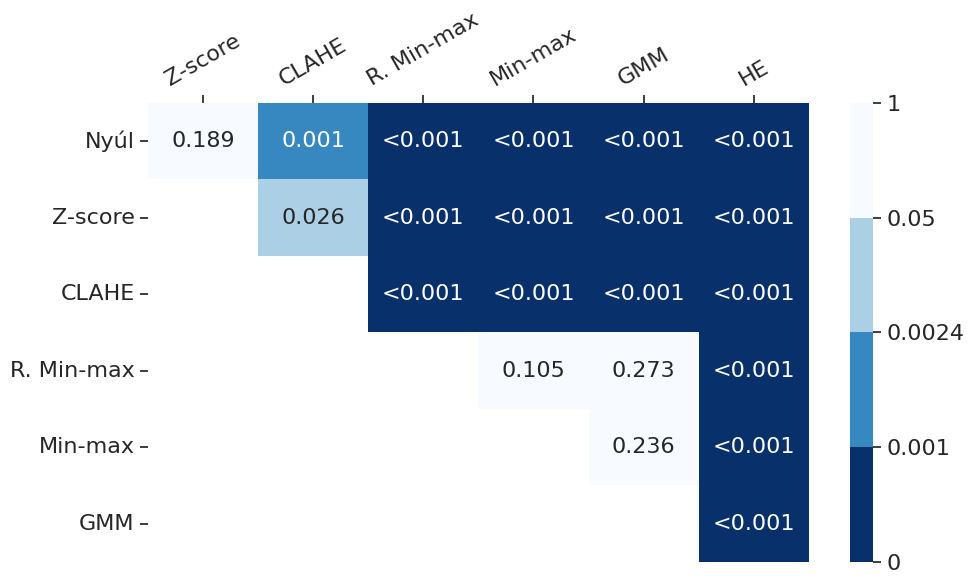

In [51]:
# Trim empty first column and bottom row
df_ext_p_values_trimmed = df_ext_p_values.iloc[:-1, 1:]

# print shape of trimmed dataframe
print(df_ext_p_values_trimmed.shape)

annot_ext_pvals = np.vectorize(format_p_value)(df_ext_p_values_trimmed.values)

print(annot_ext_pvals.shape)

# format seaborn style
sns.set_style("ticks")

# set cmap as a gradient from white to blue 
#inverted cmap
cmap = colormaps["Blues_r"]

# make heatmap of p-values
plt.figure(figsize=(10, 6))
ax = sns.heatmap(df_ext_p_values_trimmed, annot=annot_ext_pvals, cmap=cmap, norm=norm, fmt="", mask=df_ext_p_values_trimmed==0, vmin=0, vmax=1, annot_kws={"size": 16})

# Set custom colorbar ticks and labels
cbar = ax.collections[0].colorbar
cbar.set_ticks(bounds)  # Explicitly include 0.0024
cbar.set_ticklabels(tick_labels)  # Force 0.0024 as a label
cbar.ax.tick_params(labelsize=16)

# move x ticks to top
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

# Adjust tick labels
plt.xticks(fontsize=16, rotation=30)
plt.yticks(fontsize=16, rotation=0)
plt.tight_layout()
plt.savefig('p_values_external_dice_scores_Blues.pdf', format='pdf', dpi=800, bbox_inches='tight')
plt.show()

In [52]:
# Repeat pairwise wilcoxon but with different correction
# use benjamini-hochberg correction for multiple comparisons
methods = external_all_dice_medians.index.tolist()

# get all p-values
p_values = []
comparisons = []
for i, method1 in enumerate(methods):
    for j, method2 in enumerate(methods):
        if i < j:
            t_stat, p_val = wilcoxon(external_all_df[method1], external_all_df[method2])
            p_values.append(p_val)
            comparisons.append((method1, method2))
# apply benjamini-hochberg correction
corrected_pvals = multipletests(p_values, method='fdr_bh')[1]
# print significant results
for i, (method1, method2) in enumerate(comparisons):
    if corrected_pvals[i] < 0.05:
        print(f"{method1} vs {method2}: p-value = {corrected_pvals[i]:.7f} (BH corrected)")

Z-score vs CLAHE: p-value = 0.0321393 (BH corrected)
Z-score vs R. Min-max: p-value = 0.0000000 (BH corrected)
Z-score vs GMM: p-value = 0.0000000 (BH corrected)
Z-score vs Min-max: p-value = 0.0000000 (BH corrected)
Z-score vs HE: p-value = 0.0000000 (BH corrected)
Nyúl vs CLAHE: p-value = 0.0019574 (BH corrected)
Nyúl vs R. Min-max: p-value = 0.0000000 (BH corrected)
Nyúl vs GMM: p-value = 0.0000000 (BH corrected)
Nyúl vs Min-max: p-value = 0.0000000 (BH corrected)
Nyúl vs HE: p-value = 0.0000000 (BH corrected)
CLAHE vs R. Min-max: p-value = 0.0000610 (BH corrected)
CLAHE vs GMM: p-value = 0.0000798 (BH corrected)
CLAHE vs Min-max: p-value = 0.0000013 (BH corrected)
CLAHE vs HE: p-value = 0.0000000 (BH corrected)
R. Min-max vs HE: p-value = 0.0000001 (BH corrected)
GMM vs HE: p-value = 0.0000074 (BH corrected)
Min-max vs HE: p-value = 0.0000109 (BH corrected)


In [53]:
# Can see that Zscore, CLAHE, and Nyúl are not significantly different
# from each other, but are significantly different from HE, GMM, min-max and robust min-max

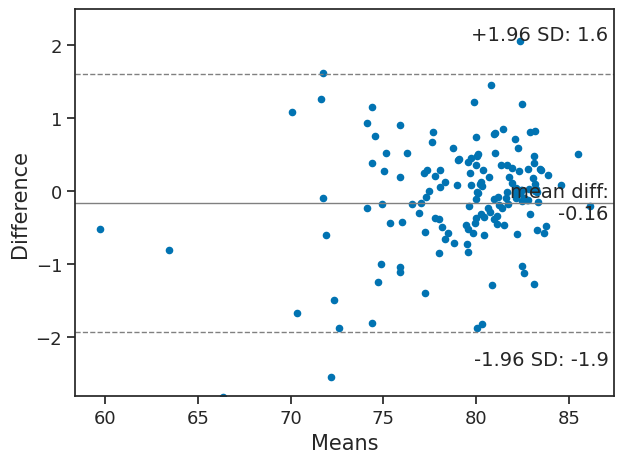

In [54]:
# bland-altman plot for zscore and zscore hist match
sm.graphics.mean_diff_plot(external_all_df["Z-score"], external_all_df["Nyúl"])
plt.show()

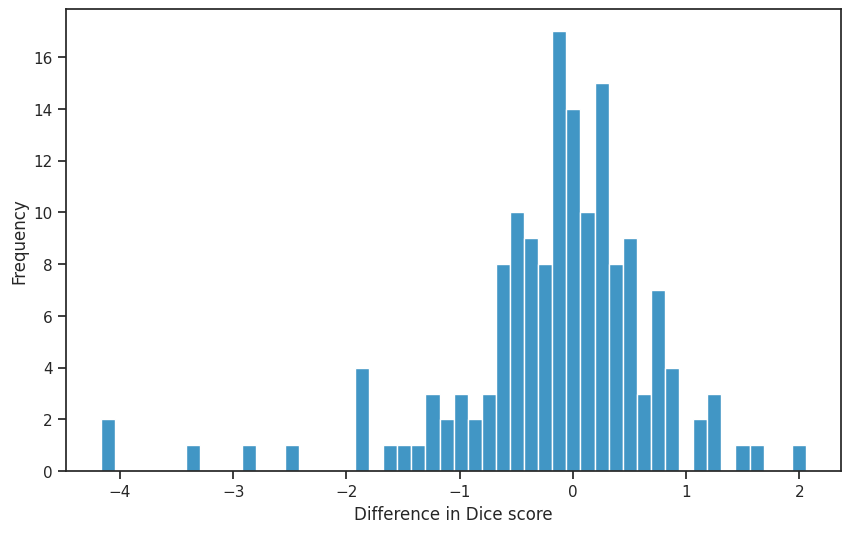

p-value = 0.0000
0.8829090376717147


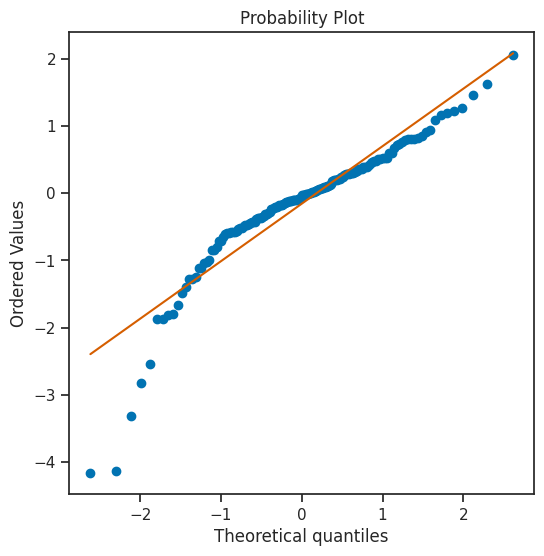

In [55]:
# Plot differences between two methods to check if they are normally distributed
# and if we can use t-test or wilcoxon test
diff = external_all_df["Z-score"] - external_all_df["Nyúl"]

plt.figure(figsize=(10, 6))
sns.histplot(diff, bins=50)
plt.xlabel("Difference in Dice score")
plt.ylabel("Frequency")
plt.show()

# perform shapiro-wilk test to check for normality
from scipy.stats import shapiro

stat, p_val = shapiro(diff)
print(f"p-value = {p_val:.4f}")
print(stat)

# plot q-q plot
import scipy.stats as stats

plt.figure(figsize=(6, 6))
stats.probplot(diff, plot=plt)
plt.show()

## Look at images that have most performance variance

In [54]:
# across external dataframe, get mean and standard deviation of dice scores across images 
# to see which images vary the most in dice score across methods, and which are more consistent
external_means = external_all_df.mean(axis=1)
external_stds = external_all_df.std(axis=1)

# add to dataframe
external_all_df["Mean"] = external_means
external_all_df["Std"] = external_stds
external_all_df.head()

,Z-score,Min-max,R. Min-max,HE,CLAHE,Nyúl,GMM,Mean,Std
0,80.279842,79.928753,80.192836,80.126713,80.330559,80.185203,79.931339,80.139321,0.157608
1,80.597486,80.664459,80.543079,79.832012,80.892747,80.880864,80.485006,80.556522,0.356320
2,82.420316,81.804615,82.013961,81.932241,81.715126,82.554881,81.935379,82.053788,0.314271
3,79.757396,79.706789,79.885147,79.510035,79.919987,79.360876,79.845018,79.712178,0.207002
4,82.373550,82.036228,82.280699,81.970770,82.547913,82.397004,81.892362,82.214075,0.248028


In [57]:
# sort by standard deviation to see which images vary the most in dice score across methods
external_all_df_sorted = external_all_df.sort_values(by="Std", ascending=False)
external_all_df_sorted.head(10)

,Z-score,Min-max,R. Min-max,HE,CLAHE,Nyúl,GMM,Mean,Std
77,79.711132,73.855762,73.297540,82.364269,80.059630,83.028679,72.316942,77.804850,4.524432
53,74.301681,68.737456,68.661329,76.652839,76.157438,78.435378,68.577038,73.074737,4.302465
111,64.949984,64.259448,61.640651,66.915288,60.690450,67.767533,62.447210,64.095795,2.662379
127,79.382537,76.370084,76.515607,79.625409,81.272660,81.197261,74.701373,78.437847,2.578280
52,77.599805,76.186086,73.197515,76.742900,77.828452,78.441899,74.416416,76.344725,1.914063
87,74.414569,75.541082,75.395914,77.647207,76.806234,78.579327,74.116374,76.071530,1.664211
128,70.925740,69.541371,72.282400,72.165694,72.765050,73.470640,71.168029,71.759846,1.312926
121,71.589096,71.664786,71.795928,69.386526,72.966775,73.078125,72.981890,71.923304,1.302116
83,82.093445,80.297757,80.136087,82.264274,82.413085,81.769400,79.324564,81.185516,1.237501
126,73.485830,74.222662,73.021784,73.099949,76.002615,75.286067,73.245495,74.052057,1.175847


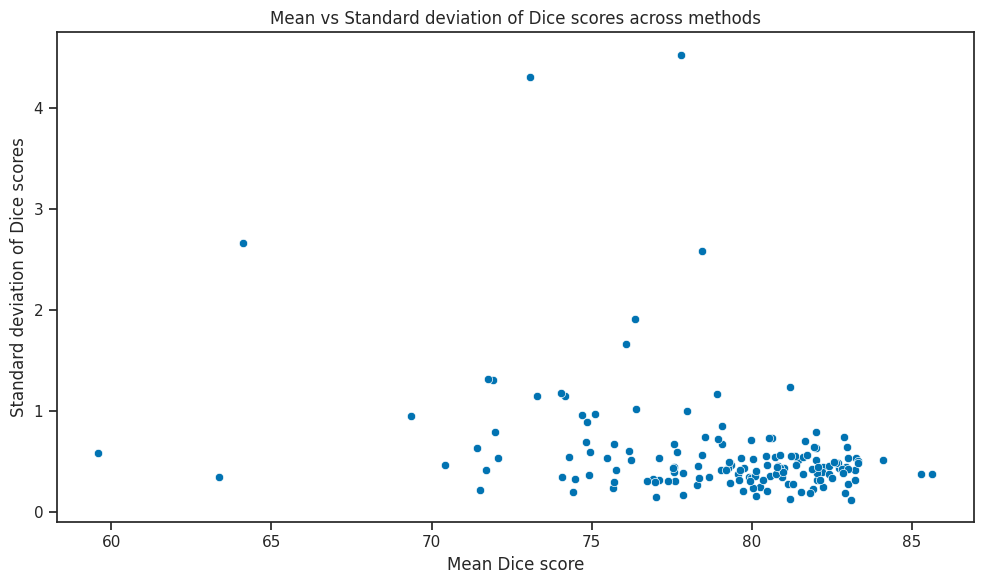

In [56]:
# do lower mean dice scores correspond to higher standard deviation? plot mean vs std
plt.figure(figsize=(10, 6))
sns.scatterplot(data=external_all_df, x="Mean", y="Std")
plt.xlabel("Mean Dice score")
plt.ylabel("Standard deviation of Dice scores")
plt.title("Mean vs Standard deviation of Dice scores across methods")
plt.tight_layout()
plt.show()

### Try visualising the differences across the images with the most variation

In [58]:
# get index of image with highest standard deviation
index_highest_std = external_all_df["Std"].idxmax()
print(f"Image with highest standard deviation: {index_highest_std}, Std: {external_all_df.loc[index_highest_std, 'Std']}, Mean: {external_all_df.loc[index_highest_std, 'Mean']}")

Image with highest standard deviation: 77, Std: 4.524432071295059, Mean: 77.80485048369101


In [102]:
# read in the image, label, and all predictions for the image with the highest standard deviation in dice scores across methods
index_highest_std = 127
im_name = f"SKMTEA_{index_highest_std+1:03d}_0000.nii.gz"
seg_name = f"SKMTEA_{index_highest_std+1:03d}.nii.gz"

# paths
im_path = os.path.join(data_path, '../images_all_skmtea', im_name)
gt_path = os.path.join(data_path, '../labels_all_skmtea', seg_name)

# method predictions
method_pred_paths = {}
for folder in subfolders:
    pred_path = os.path.join(data_path, folder, seg_name)
    method_pred_paths[folder] = pred_path

In [103]:
method_pred_paths

{'zscore_preds_all_skmtea': '../nnUNet_data/nnUNet_raw/Dataset361_Menisci/skmtea_external_results/zscore_preds_all_skmtea/SKMTEA_128.nii.gz',
 'rescale_preds_all_skmtea': '../nnUNet_data/nnUNet_raw/Dataset361_Menisci/skmtea_external_results/rescale_preds_all_skmtea/SKMTEA_128.nii.gz',
 'clip_rescale_preds_all_skmtea': '../nnUNet_data/nnUNet_raw/Dataset361_Menisci/skmtea_external_results/clip_rescale_preds_all_skmtea/SKMTEA_128.nii.gz',
 'hist_eq_preds_all_skmtea': '../nnUNet_data/nnUNet_raw/Dataset361_Menisci/skmtea_external_results/hist_eq_preds_all_skmtea/SKMTEA_128.nii.gz',
 'clahe_preds_all_skmtea': '../nnUNet_data/nnUNet_raw/Dataset361_Menisci/skmtea_external_results/clahe_preds_all_skmtea/SKMTEA_128.nii.gz',
 'nyul_preds_all_skmtea': '../nnUNet_data/nnUNet_raw/Dataset361_Menisci/skmtea_external_results/nyul_preds_all_skmtea/SKMTEA_128.nii.gz',
 'gmm_preds_all_skmtea': '../nnUNet_data/nnUNet_raw/Dataset361_Menisci/skmtea_external_results/gmm_preds_all_skmtea/SKMTEA_128.nii.gz'}

(160, 266, 341)
(160, 266, 341)


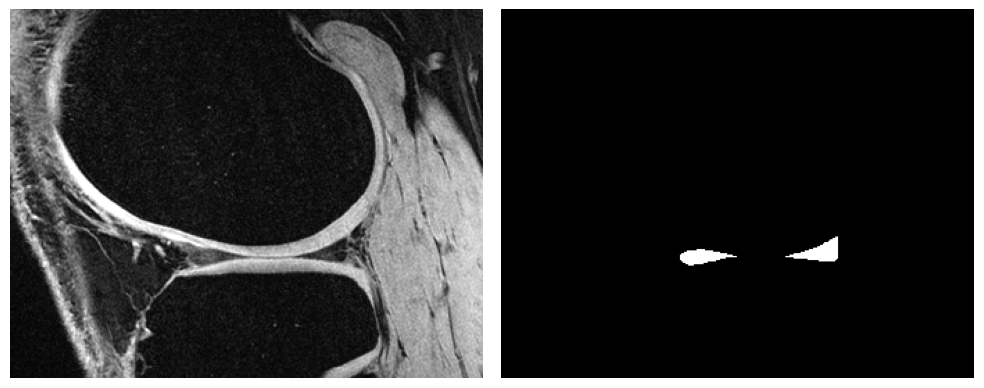

In [104]:
# load image
image = sitk.ReadImage(im_path)
image_array = sitk.GetArrayFromImage(image)
print(image_array.shape)

label = sitk.ReadImage(gt_path)
label_array = sitk.GetArrayFromImage(label)
print(label_array.shape)

# plot a slice of image and label
plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(image_array[115,:], vmax=np.percentile(image_array[115,:], 99.5), cmap="gray")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(label_array[115,:], cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()

In [105]:
# load all predictions into a dictionary of arrays
pred_arrays = {}
for method, path in method_pred_paths.items():
    pred = sitk.ReadImage(path)
    pred_array = sitk.GetArrayFromImage(pred)
    pred_arrays[method] = pred_array
    print(f"{method}: {pred_array.shape}")

zscore_preds_all_skmtea: (160, 266, 341)
rescale_preds_all_skmtea: (160, 266, 341)
clip_rescale_preds_all_skmtea: (160, 266, 341)
hist_eq_preds_all_skmtea: (160, 266, 341)
clahe_preds_all_skmtea: (160, 266, 341)
nyul_preds_all_skmtea: (160, 266, 341)
gmm_preds_all_skmtea: (160, 266, 341)


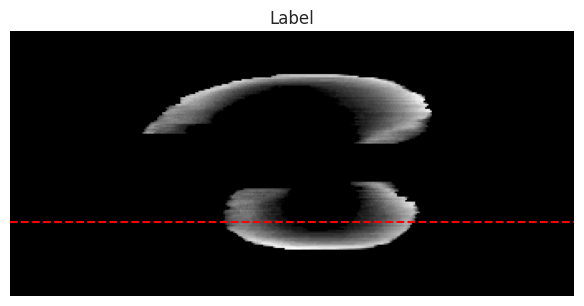

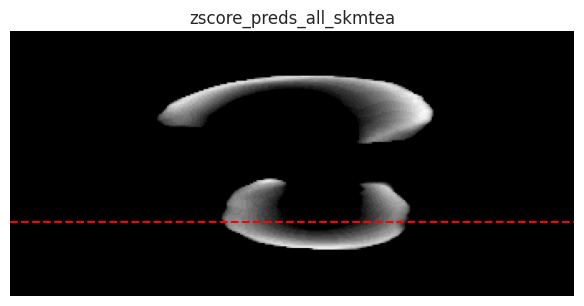

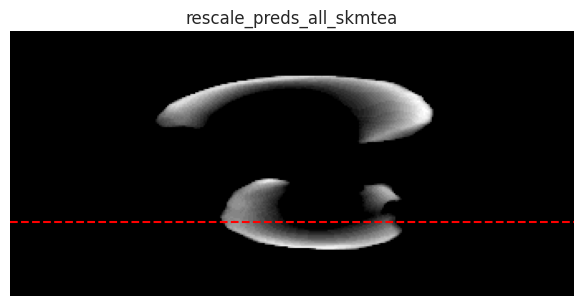

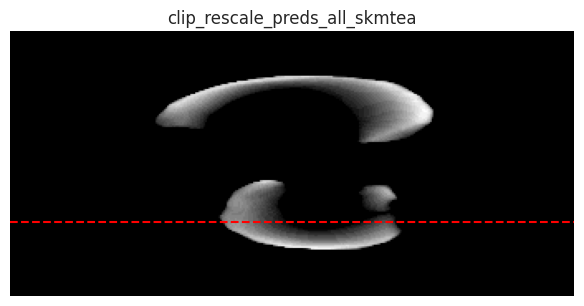

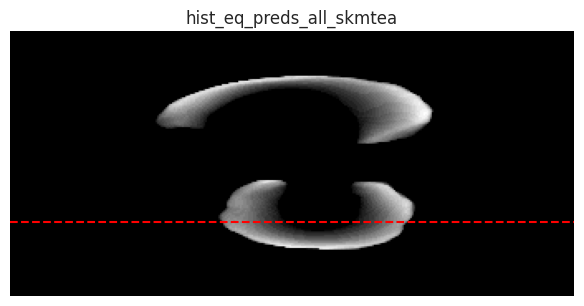

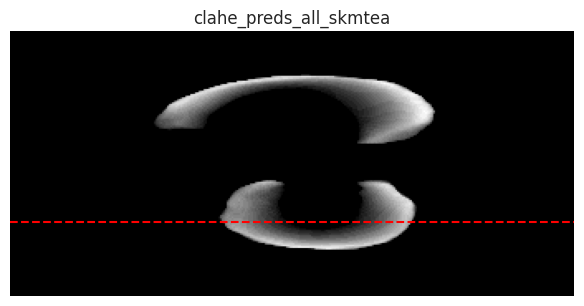

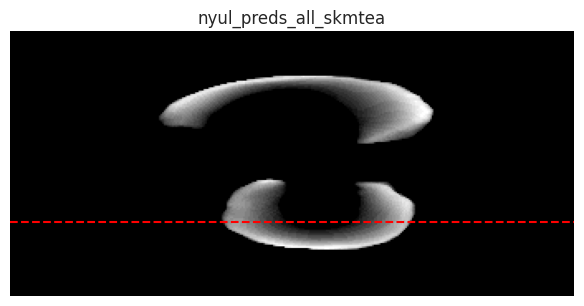

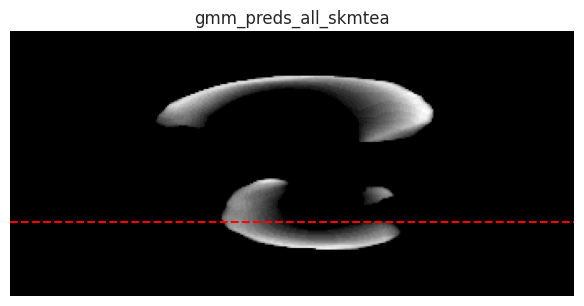

In [106]:
# for each prediction, plot the sum through the y axis
plt.figure(figsize=(6, 6))
plt.imshow(np.sum(label_array, axis=1), cmap="gray")
# draw red line
plt.axhline(y=115, color='red', linestyle='--')
plt.title("Label")
plt.axis("off")
plt.tight_layout()
plt.show()

for method, pred_array in pred_arrays.items():
    plt.figure(figsize=(6, 6))
    plt.imshow(np.sum(pred_array, axis=1), cmap="gray")
    plt.axhline(y=115, color='red', linestyle='--')
    plt.title(method)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

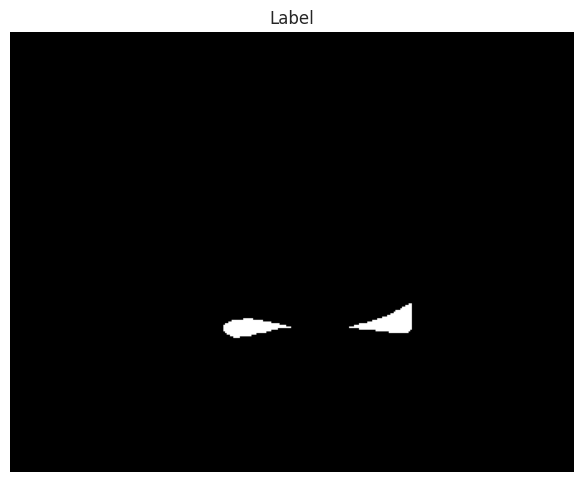

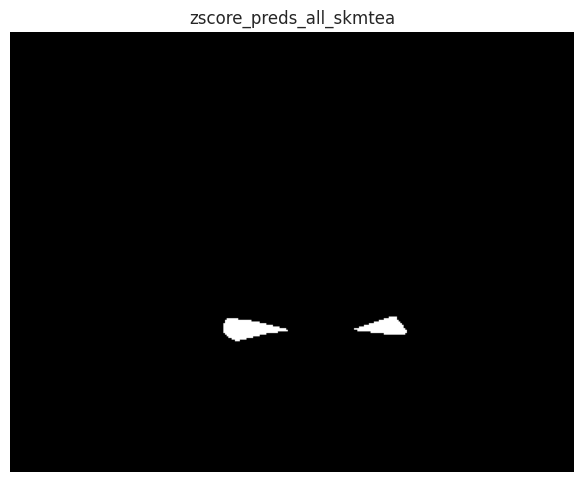

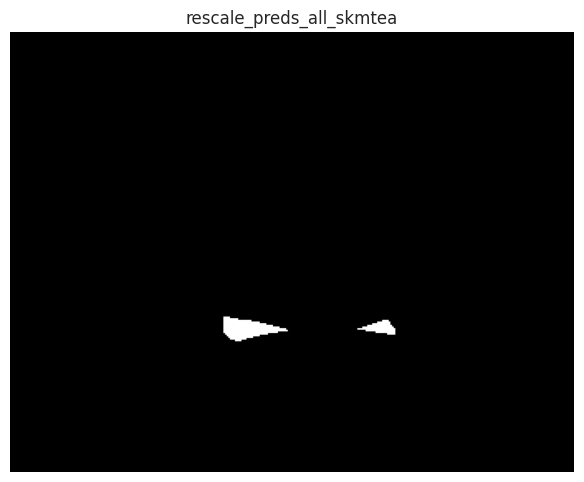

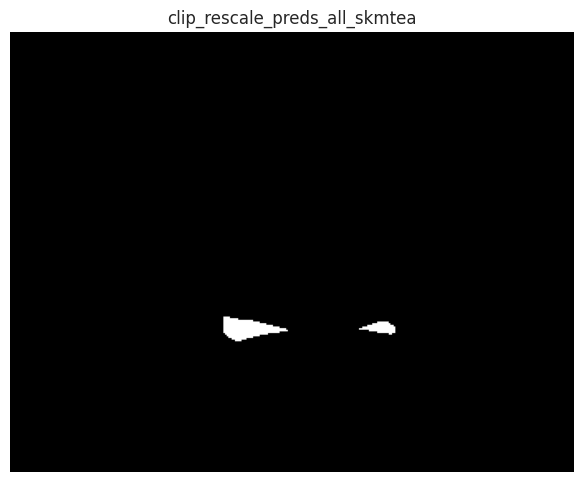

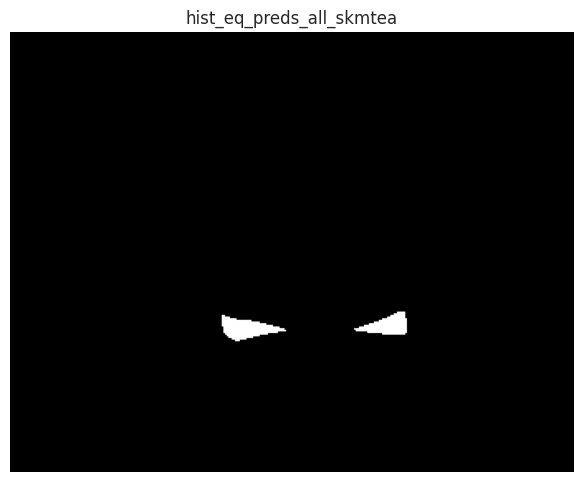

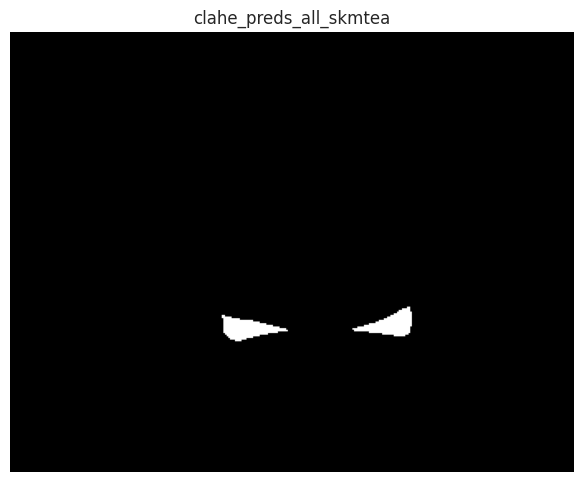

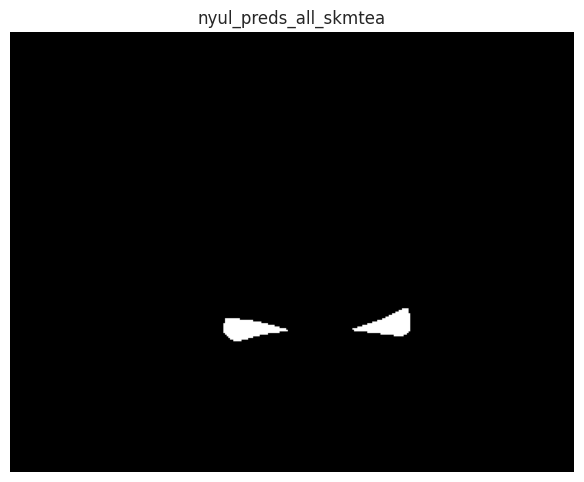

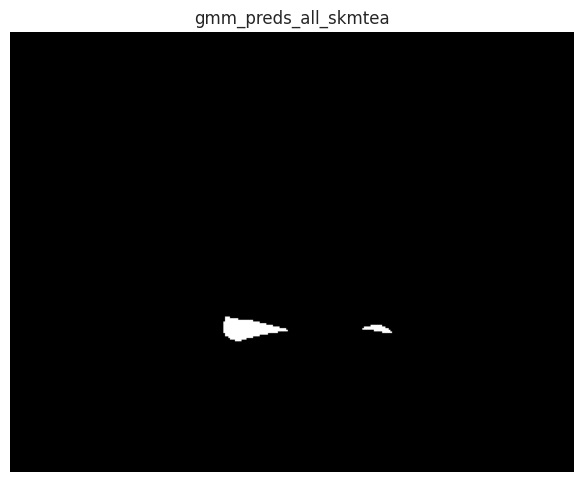

In [107]:
# for each prediction, plot 115th slice
plt.figure(figsize=(6, 6))
plt.imshow(label_array[115,:], cmap="gray")
plt.title("Label")
plt.axis("off")
plt.tight_layout()
plt.show()

for method, pred_array in pred_arrays.items():
    plt.figure(figsize=(6, 6))
    plt.imshow(pred_array[115,:], cmap="gray")
    plt.title(method)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

## Now do hausdorff

In [ ]:
# get hausdorff distances from all external folders
external_all_hd_df = pd.DataFrame()

for folder in subfolders:
    json_path = os.path.join(data_path, folder, 'summary.json')
    hausdorff_distances = get_hausdorff_distances(json_path)
    external_all_hd_df[folder] = hausdorff_distances

external_all_hd_df.head()

In [ ]:
# rename columns
external_all_hd_df.columns = [
    "Z-score",
    "Min-max",
    "R. min-max",
    "HE",
    "CLAHE",
    "Nyúl",
    "GMM"
]

In [ ]:
external_all_hd_df.describe()

In [ ]:
# plot box plot of hausdorff distances
plt.figure(figsize=(10, 6))
sns.boxplot(data=external_all_hd_df)
plt.ylabel("Hausdorff distance")
plt.savefig('boxplot_external_all_hausdorff_distances.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# check if there is a significant difference between the methods
# Friedman test
# reorder data into correct format
data = external_all_hd_df.T.values

# perform friedman test
stat, p = friedmanchisquare(*data)
print(f"Friedman test statistic: {stat}, p-value: {p}")

# if p < 0.05, perform post-hoc tests
if p < 0.05:
    print("Friedman test is significant, can post-hoc tests")

In [ ]:
# get medians
external_all_hd_medians = external_all_hd_df.median()
# order columns by increasing median
external_all_hd_medians = external_all_hd_medians.sort_values(ascending=True)
# print medians
print("Medians:\n",external_all_hd_medians)

In [ ]:
# check if there is a significant difference between the methods
# perform wilcoxon test between all pairs of methods
# Use Bonferroni correction for multiple comparisons
methods = external_all_hd_medians.index.tolist()
# number of comparisons
n_comparisons = len(methods) * (len(methods) - 1) / 2
alpha = 0.05 / n_comparisons
print(f"Bonferroni corrected alpha: {alpha}")

# for each pair of methods, perform wilcoxon test
for i, method1 in enumerate(methods):
    for j, method2 in enumerate(methods):
        if i < j:
            t_stat, p_val = wilcoxon(external_all_hd_df[method1], external_all_hd_df[method2])
            significant = "(SIG)" if p_val < alpha else ""
            if p_val < alpha:
                print(f"{method1} vs {method2}: p-value = {p_val:.7f} {significant}")

In [ ]:
# get index of 2nd highest zscore hausdorff distance
external_all_hd_df.sort_values("Zscore", ascending=False).head(10)

In [ ]:
worst_im = 121

In [ ]:
# plot this image, along with the mask and prediction
# load image
skmtea_all_im_path = os.path.join(data_path, '../images_all_skmtea')
image_paths = [f.path for f in os.scandir(skmtea_all_im_path) if f.is_file()]
image_paths.sort()

# load image
image = sitk.ReadImage(image_paths[worst_im])
image_array = sitk.GetArrayFromImage(image)

# load mask
skmtea_all_mask_path = os.path.join(data_path, '../labels_all_skmtea')
mask_paths = [f.path for f in os.scandir(skmtea_all_mask_path) if f.is_file()]
mask_paths.sort()

mask = sitk.ReadImage(mask_paths[worst_im])
mask_array = sitk.GetArrayFromImage(mask)

# load prediction
zscore_all_preds_path = os.path.join(data_path, 'zscore_hist_match_preds_all_skmtea')
pred_paths = [f.path for f in os.scandir(zscore_all_preds_path) if f.is_file()]
pred_paths.sort()

pred = sitk.ReadImage(pred_paths[worst_im])
pred_array = sitk.GetArrayFromImage(pred)

In [ ]:
# now plot the image, mask, and prediction
plt.figure(figsize=(18, 10))
plt.subplot(1, 3, 1)
plt.imshow(image_array[100,...], cmap="gray")
plt.title("Image")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(mask_array[100,...], cmap="gray")
plt.title("Mask")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(pred_array[100,...], cmap="gray")
plt.title("Prediction")
plt.axis("off")
plt.show()

In [ ]:
# show mask and prediction, summed through axis 1
plt.figure(figsize=(18, 10))
plt.subplot(1, 2, 1)
plt.imshow(np.sum(mask_array, axis=1), cmap="gray")
plt.title("Mask")
plt.subplot(1, 2, 2)
plt.imshow(np.sum(pred_array, axis=1), cmap="gray")
plt.title("Prediction")
plt.show()

In [ ]:
# look at slices 40-80, 5 slice at a time
for i in range(30, 80, 5):
    plt.figure(figsize=(18, 10))
    plt.subplot(1, 3, 1)
    plt.imshow(image_array[i,...], cmap="gray")
    plt.title("Image")
    plt.axis("off")
    plt.subplot(1, 3, 2)
    plt.imshow(mask_array[i,...], cmap="gray")
    plt.title("Mask")
    plt.axis("off")
    plt.subplot(1, 3, 3)
    plt.imshow(pred_array[i,...], cmap="gray")
    plt.title("Prediction")
    plt.axis("off")
    plt.show()